# AIRPATH-AI P0-2A — static vs arrival-time exposure

Development/exploratory comparison of static/current pollution exposure versus
hourly forecast-bucket-aware arrival-time exposure using `C_xgboost_current_pm`.

This notebook loads the saved experiment artifacts. To regenerate from scratch:
`python3 -m src.static_vs_arrival_exposure`.

This does not claim minute-level PM2.5 accuracy or untouched final-test performance.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT = PROJECT_ROOT / "data/processed/static_vs_arrival_exposure"

In [2]:
edge_cases = pd.read_csv(OUTPUT / "edge_case_summary.csv")
mode_summary = pd.read_csv(OUTPUT / "mode_tolerance_summary.csv")
ranking_quality = pd.read_csv(OUTPUT / "ranking_quality.csv")
route_summary = pd.read_csv(OUTPUT / "route_exposure_comparison.csv")
decision = json.loads((OUTPUT / "evidence_decision.json").read_text())
edge_cases

,delta_time_allowed_minutes,scenario_mode_cases,same_route_selected,different_routes_selected,only_one_feasible_route,no_alternative_beyond_fastest,percentage_selections_differ
0,0.0,60,60,0,60,60,0.000000
1,1.0,60,57,3,6,6,5.000000
2,2.0,60,56,4,2,2,6.666667
3,3.0,60,56,4,0,0,6.666667
4,5.0,60,56,4,0,0,6.666667
5,10.0,60,56,4,0,0,6.666667


In [3]:
mode_summary

,mode,delta_time_allowed_minutes,cases,percentage_selections_differ,mean_static_predicted_reduction_vs_fastest,mean_airpath_predicted_reduction_vs_fastest,mean_oracle_reduction_static_selected_vs_fastest,mean_oracle_reduction_airpath_selected_vs_fastest,differing_cases,mean_oracle_percent_improvement_when_differ
0,motorbike,0.0,30,0.000000,0.000000,0.000000,0.000000,0.000000,0,NaN
1,motorbike,1.0,30,6.666667,0.252323,0.030272,0.047951,0.084487,2,0.176456
2,motorbike,2.0,30,6.666667,0.252323,0.030272,0.047951,0.084487,2,0.176456
3,motorbike,3.0,30,6.666667,0.252323,0.030272,0.047951,0.084487,2,0.176456
4,motorbike,5.0,30,6.666667,0.252323,0.030272,0.047951,0.084487,2,0.176456
5,motorbike,10.0,30,6.666667,0.252323,0.030272,0.047951,0.084487,2,0.176456
6,walking,0.0,30,0.000000,0.000000,0.000000,0.000000,0.000000,0,NaN
7,walking,1.0,30,3.333333,0.371639,0.242582,1.010796,1.010565,1,-0.000351
8,walking,2.0,30,6.666667,1.069834,0.242582,0.965909,1.010565,2,0.035231
9,walking,3.0,30,6.666667,1.069834,0.242582,0.965909,1.010565,2,0.035231


In [4]:
ranking_quality.describe(include="all")

,scenario_id,mode,route_count,spearman_static_vs_airpath,kendall_tau_a_static_vs_airpath,top_1_agreement,routes_with_material_rank_change,percentage_routes_with_material_rank_change
count,60,60,60.0,60.000000,60.000000,60,60.000000,60.000000
unique,30,2,NaN,NaN,NaN,2,NaN,NaN
top,od_01,motorbike,NaN,NaN,NaN,True,NaN,NaN
freq,2,30,NaN,NaN,NaN,56,NaN,NaN
mean,NaN,NaN,8.0,0.992460,0.978571,NaN,0.583333,7.291667
std,NaN,NaN,0.0,0.016102,0.044208,NaN,1.197337,14.966712
min,NaN,NaN,8.0,0.928571,0.857143,NaN,0.000000,0.000000
25%,NaN,NaN,8.0,1.000000,1.000000,NaN,0.000000,0.000000
50%,NaN,NaN,8.0,1.000000,1.000000,NaN,0.000000,0.000000
75%,NaN,NaN,8.0,1.000000,1.000000,NaN,0.000000,0.000000


In [5]:
{
    "n_scenarios": route_summary["scenario_id"].nunique(),
    "n_routes": len(route_summary),
    "mean_static": route_summary["static_exposure_index"].mean(),
    "mean_airpath": route_summary["airpath_exposure_index"].mean(),
    "decision": decision,
}

{'n_scenarios': 30,
 'n_routes': 480,
 'mean_static': np.float64(871.3000360895371),
 'mean_airpath': np.float64(874.7673451423509),
 'decision': {'classification': 'B. MIXED EVIDENCE',
  'rationale': 'Static and AIRPATH frameworks sometimes reorder or reselect routes, but oracle gains when selections differ are weak, inconsistent, or limited.',
  'criteria': {'evaluation_status': 'development_exploratory_not_untouched_final',
   'forecaster': 'C_xgboost_current_pm',
   'nontrivial_selection_difference_rate': 0.06333333333333334,
   'mean_oracle_percent_improvement_when_differ': 0.1076873292175646,
   'positive_oracle_gain_rate_when_differ': 0.7368421052631579,
   'mean_spearman_static_vs_airpath': 0.9924603174603174,
   'mean_percentage_routes_with_material_rank_change': 7.291666666666667,
   'five_minute_selection_difference_percentage': 6.666666666666667,
   'strong_differ_rate_ge_0_25': False,
   'strong_oracle_gain_ge_1_0': False,
   'strong_positive_gain_rate_ge_0_60': True,
   '

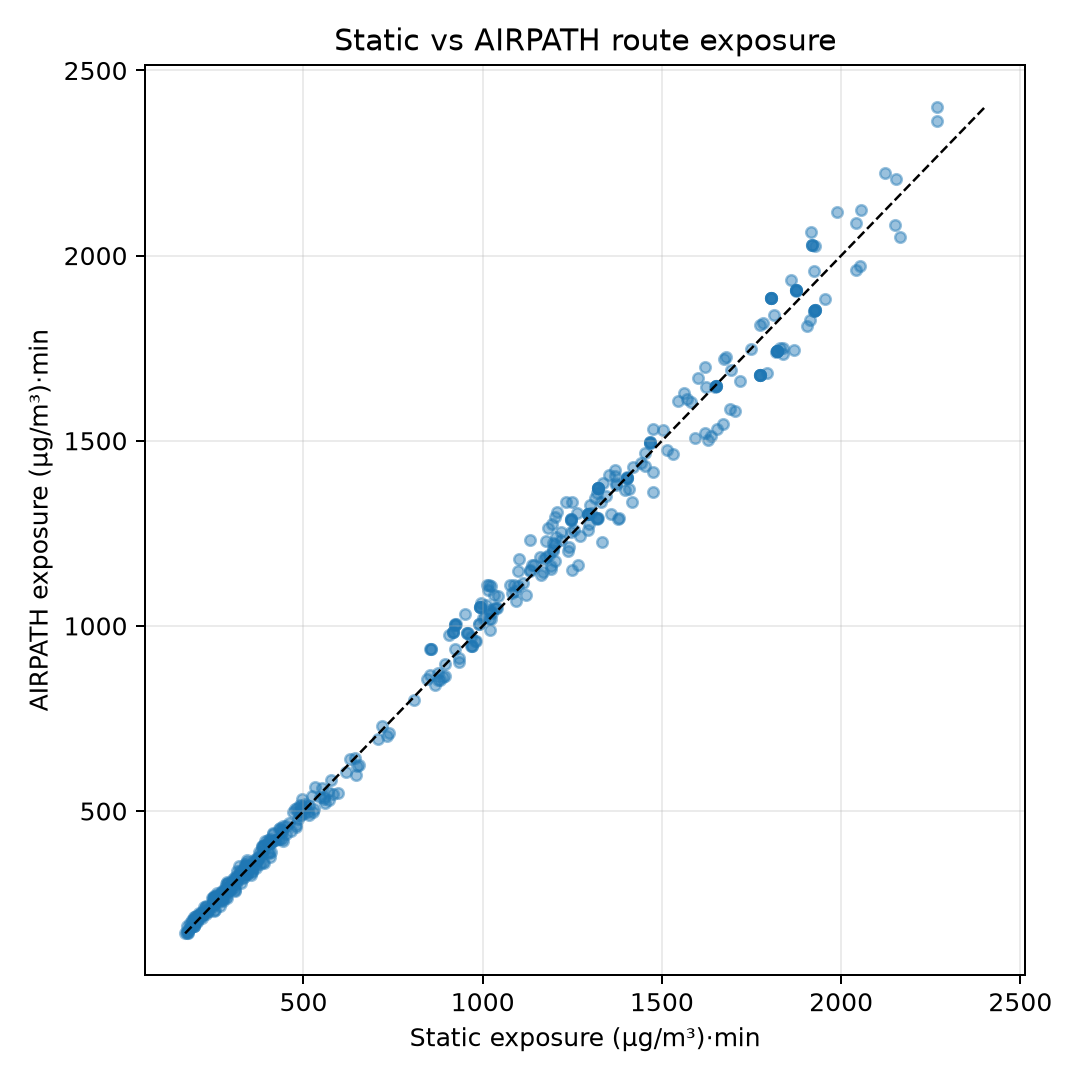

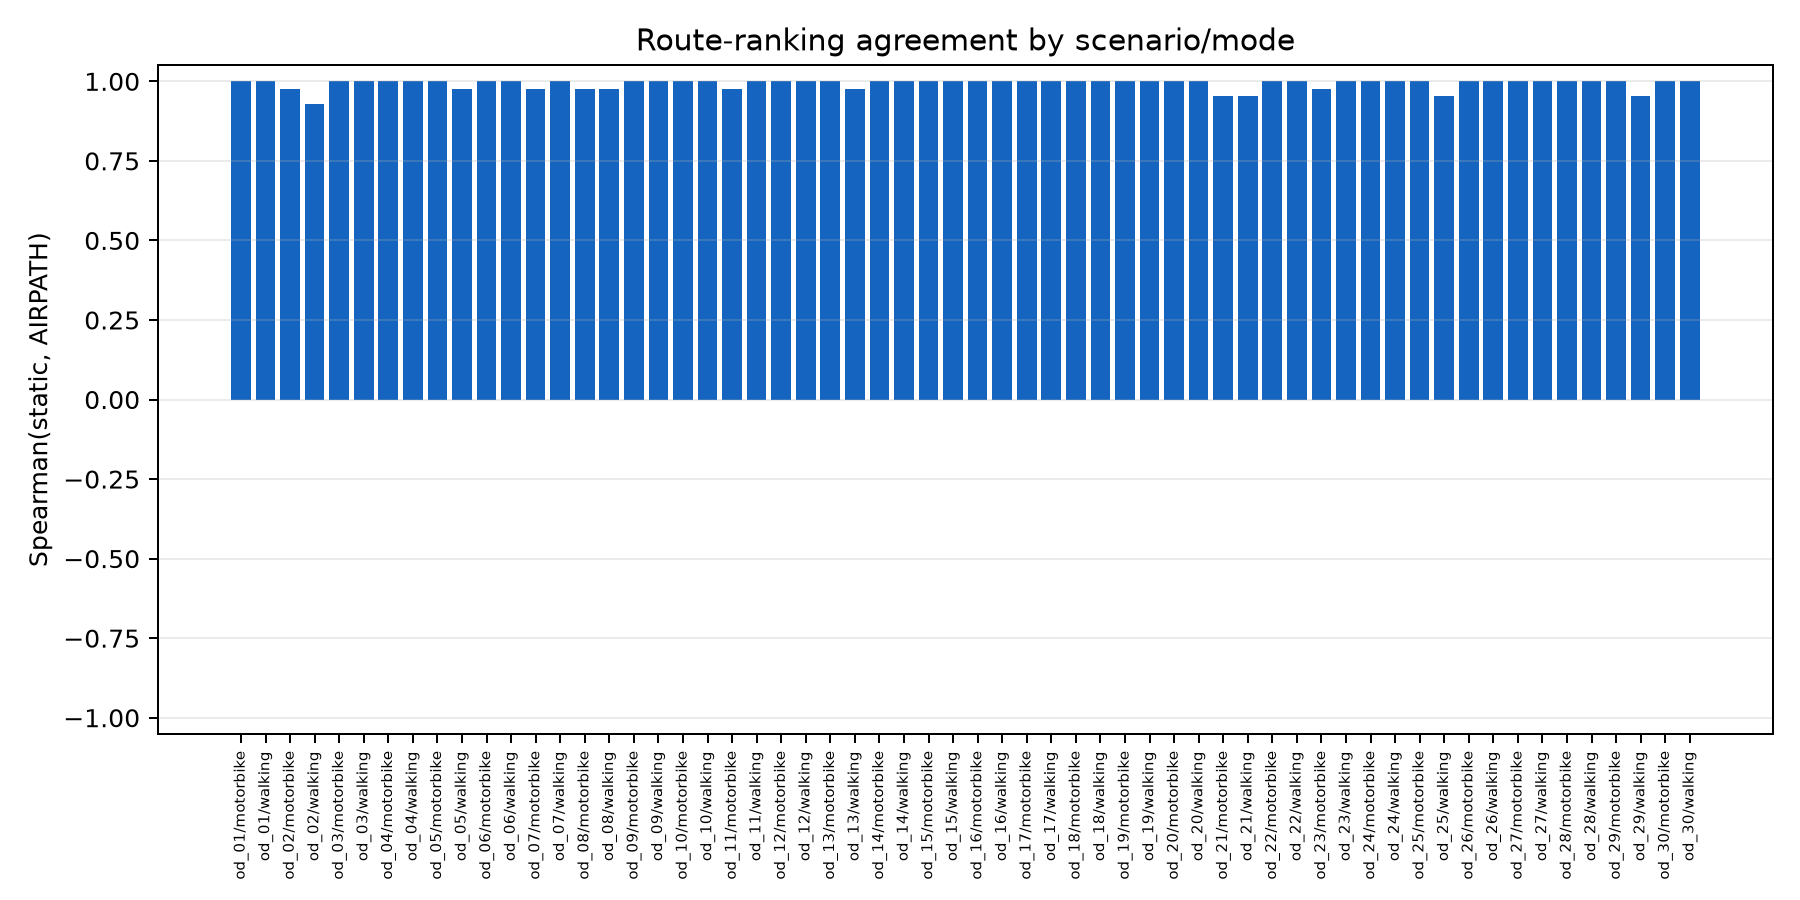

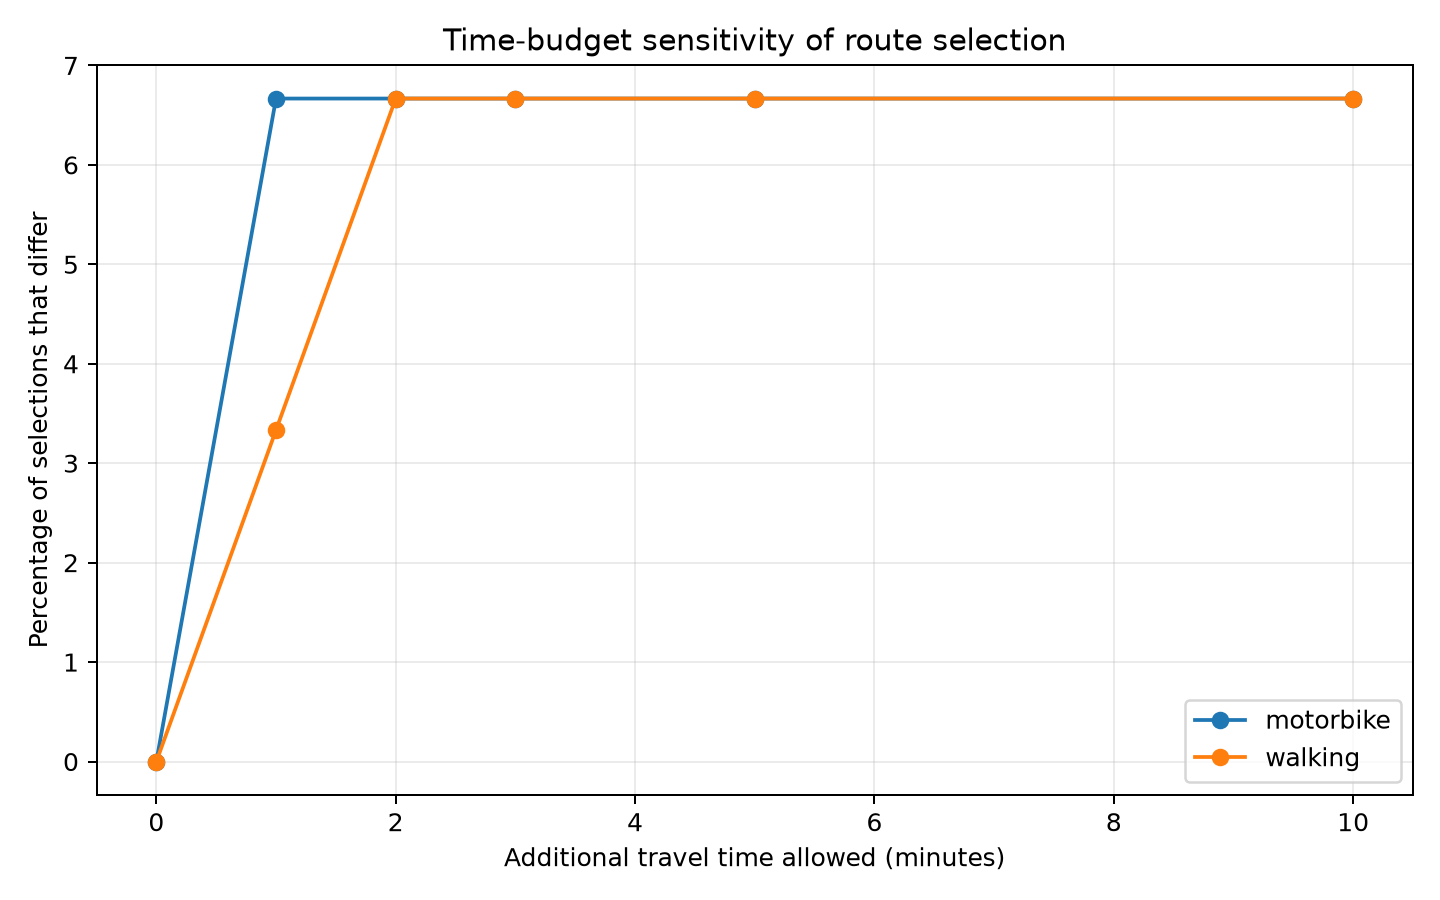

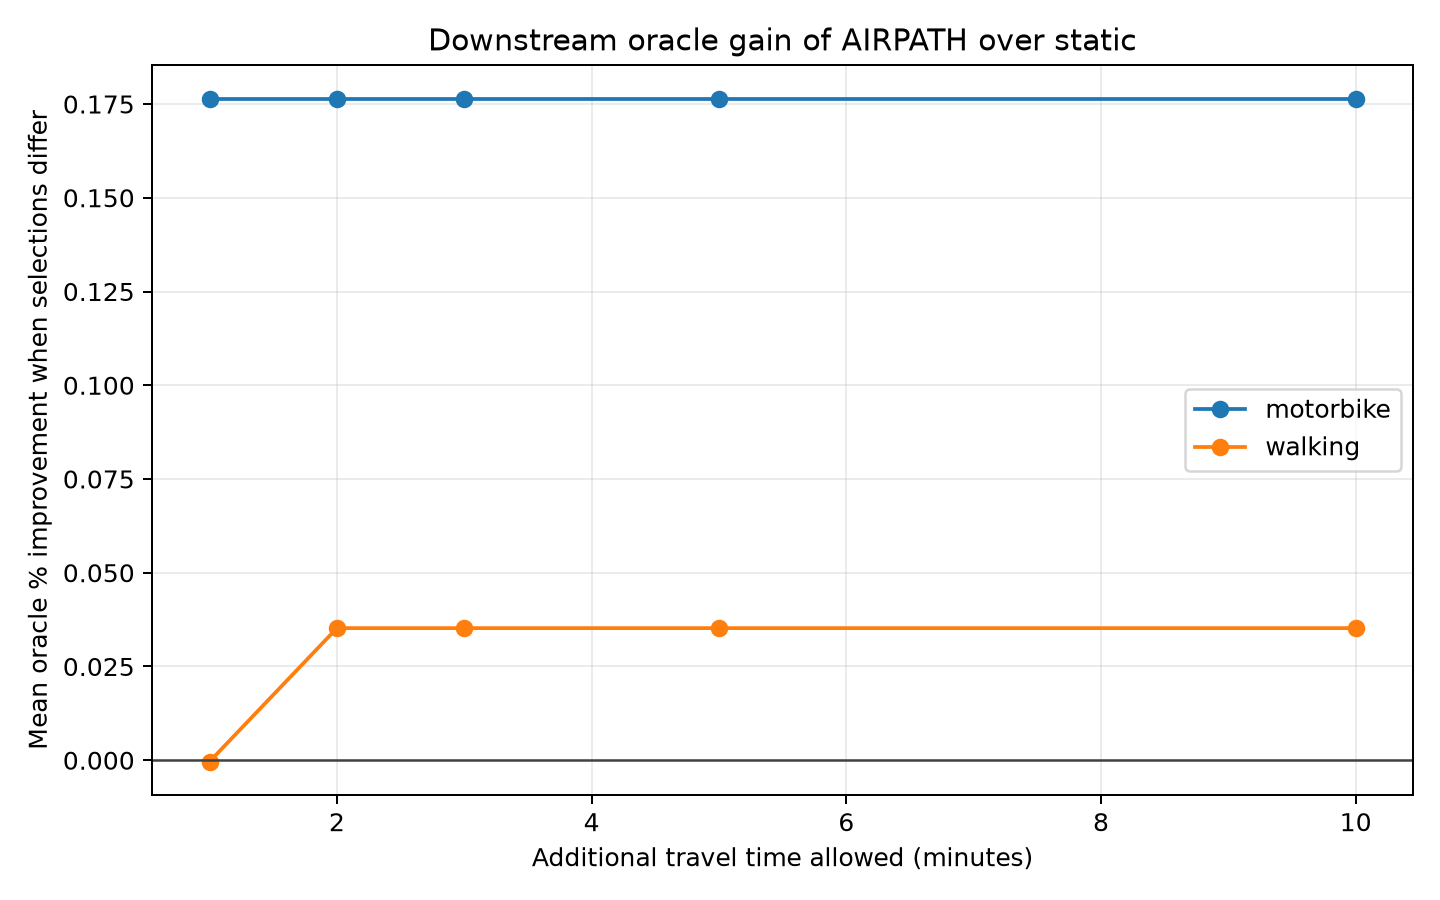

In [6]:
for name in (
    "static_vs_airpath_exposure_scatter.png",
    "ranking_correlation.png",
    "selection_difference_by_tolerance.png",
    "oracle_gain_when_differ.png",
):
    display(Image(filename=str(OUTPUT / name)))